<a href="https://colab.research.google.com/github/Mikhailo88/MN-Praktychni-K4/blob/main/%D0%9B%D0%B12_2_%D0%9E%D0%BB%D1%8C%D1%85%D0%BE%D0%B2%D0%B5%D0%BD%D0%BA%D0%BE_%D0%A4%D0%86%D0%A2_4_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import seaborn as sns
import math

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [23]:
from google.colab import files

uploaded = files.upload()

Saving titanic.csv to titanic (1).csv


In [24]:
df = pd.read_csv("titanic.csv")

In [25]:
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Набір даних зазвичай містить такі стовпці:

PassengerId: Унікальний ідентифікатор для кожного пасажира.

Survived: У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

Pclass (Клас квитка): Показник соціально-економічного статусу, де 1 – найвищий клас, а 3 – найнижчий.

Name: Ім'я пасажира.

Sex: Стать пасажира.

Age: Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)

SibSp: Кількість братів і сестер або подружжя пасажира на борту «Титаніка».

Parch: Кількість батьків або дітей пасажира на борту «Титаніка».

Ticket: Номер квитка.

Fare: Сума грошей, яку пасажир сплатив за квиток.

Головна мета використання цього набору даних — передбачити, чи вижив пасажир, на основі різних ознак. Він слугує популярним вступним набором даних для тих, хто вивчає аналіз даних, машинне навчання та прогнозне моделювання. Майте на увазі, що набір даних може змінюватися та оновлюватися, тому завжди гарною ідеєю є перевірити веб-сайт Kaggle або документацію набору даних, щоб отримати найактуальнішу інформацію.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [27]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Замінюємо пропущені значення на середнє

In [28]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Fare"] = df["Fare"].fillna(df["Fare"].mean())

# Текстові дані
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [29]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [30]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


In [31]:
df["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [32]:
df["Sex"] = df["Sex"].str.strip().str.lower().map({"male": 0,"female": 1})

print(df.dtypes)

Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


In [33]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,32.204208
std,0.486592,0.836071,0.477990,13.002015,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,29.699118,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


In [34]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


In [35]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


In [36]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.000000,13.00
887,1,1,1,19.000000,30.00
888,0,3,1,29.699118,23.45
889,1,1,0,26.000000,30.00
890,0,3,0,32.000000,7.75


In [37]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()*100

print(f"Чоловіки: {survival_by_sex[0]:.2f}%")
print(f"Жінки: {survival_by_sex[1]:.2f}%")

Чоловіки: 18.89%
Жінки: 74.20%


In [42]:
print(f'Кореляція: {df["Sex"].corr(df["Survived"])}')

Кореляція: 0.5433513806577555


Пасажири залежно від класа у відсотках

In [39]:
class_percent = df["Pclass"].value_counts(normalize=True) * 100

print("Розподіл пасажирів за класами:")
print(class_percent.sort_index())

Розподіл пасажирів за класами:
Pclass
1    24.242424
2    20.650954
3    55.106622
Name: proportion, dtype: float64


Виживші пасажири у відсотках

In [41]:
survival_percent = df.groupby("Pclass")["Survived"].mean() * 100

print("Відсоток тих, хто вижив залежно від класу:")
print(survival_percent)

Відсоток тих, хто вижив залежно від класу:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


In [43]:
# Розділяємо пасажирів на 6 груп за тарифом Fare
df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

# Обчислюємо частку тих, хто вижив у кожній групі
for i in range(6):
    surv_rate = (
        (df[df['Fare_Category'] == i]['Survived'] == 1).sum()
        / (df['Fare_Category'] == i).sum()
    )

    print(f'Частка тих, хто вижив у групі {i}: {surv_rate * 100:.2f}%')

Частка тих, хто вижив у групі 0: 20.51%
Частка тих, хто вижив у групі 1: 19.08%
Частка тих, хто вижив у групі 2: 36.69%
Частка тих, хто вижив у групі 3: 43.62%
Частка тих, хто вижив у групі 4: 41.78%
Частка тих, хто вижив у групі 5: 69.80%


Пасажири з дорожчими квитками мали більший шанс вижити

In [44]:
for i in range(1, 4):
  median_fare = df[df["Pclass"] == i]["Fare"].median()
  print(f"Медіана{i}: {median_fare:.2f}")

Медіана1: 60.29
Медіана2: 14.25
Медіана3: 8.05


Перший клас дорожчий за другий у 4 рази. А другий дорожчий за третій майже у 2 рази

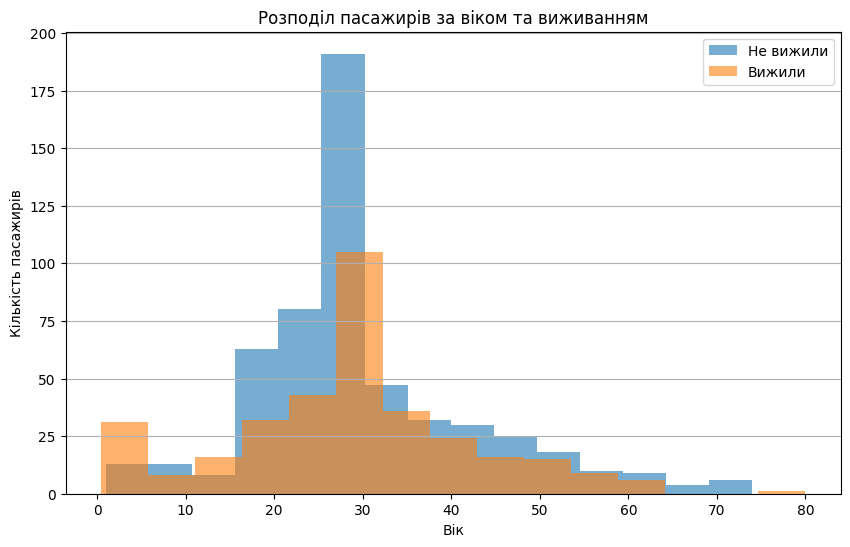

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Не вижив
plt.hist(
    df[df["Survived"] == 0]["Age"],
    bins=15,
    alpha=0.6,
    label="Не вижили"
)

# Вижив
plt.hist(
    df[df["Survived"] == 1]["Age"],
    bins=15,
    alpha=0.6,
    label="Вижили"
)

plt.xlabel("Вік")
plt.ylabel("Кількість пасажирів")
plt.title("Розподіл пасажирів за віком та виживанням")
plt.legend()
plt.grid(axis="y")

plt.show()

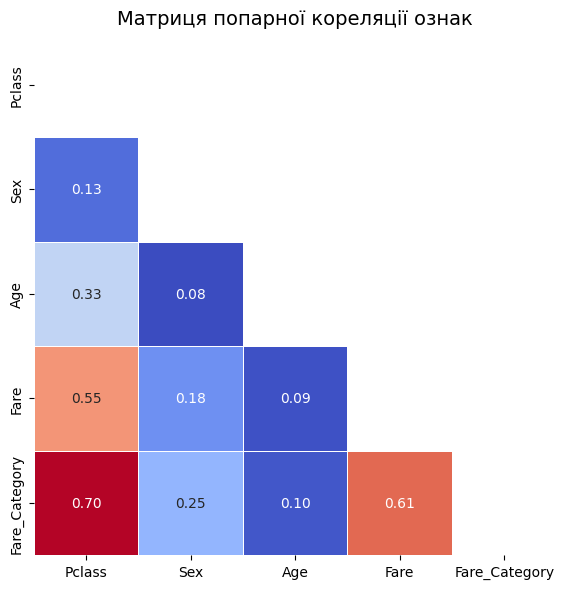

In [50]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

# Побудова теплової карти кореляцій
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.triu(np.ones_like(mtx, dtype=bool)),  # маскуємо верхній трикутник
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

**Висновок:** У ході роботи було проведено аналіз набору даних про пасажирів «Титаніка». Було виконано очищення даних, заповнення пропущених значень та перетворення текстових даних у числовий формат. Досліджено залежність виживання від статі, класу пасажира та вартості квитка, а також побудовано гістограму розподілу пасажирів за віком. За результатами аналізу можна побачити, що стать, клас пасажира та вартість квитка пов'язані з імовірністю виживання.

# Частина 2

In [52]:
import pandas as pd
import requests
from io import StringIO

url = 'https://uk.wikipedia.org/wiki/%D0%9D%D0%B0%D1%81%D0%B5%D0%BB%D0%B5%D0%BD%D0%BD%D1%8F_%D0%A3%D0%BA%D1%80%D0%B0%D1%97%D0%BD%D0%B8#%D0%9D%D0%B0%D1%80%D0%BE%D0%B4%D0%B6%D1%83%D0%B2%D0%B0%D0%BD%D1%96%D1%81%D1%82%D1%8C%22%27'

headers = {
"User-Agent": "Mozilla/5.0",
"Accept-Language": "uk-UA,uk;q=0.9,en;q=0.8",
}

html = requests.get(url, headers=headers, timeout=30).text

df = pd.read_html(
StringIO(html),
match="Коефіцієнт народжуваності в регіонах України",
thousands=".", decimal=","
)[0]

df

,Регіон,1950,1960,1970,1990,2000,2012,2014,2019
0,Крим,23.0,20.6,16.0,13.0,7.3,12.6,—,—
1,Вінницька,22.4,19.2,14.2,12.4,8.4,11.2,10.9,7.6
2,Волинська,24.7,25.0,17.9,15.3,11.2,14.8,14.1,10.1
3,Дніпропетровська,20.4,20.4,15.1,12.3,7.1,11.2,11.1,7.1
4,Донецька,27.1,21.4,14.0,10.9,6.1,9.8,8.2,—
5,Житомирська,26.1,22.3,15.9,12.9,8.9,12.2,12.0,7.9
6,Закарпатська,31.4,27.3,20.7,16.8,11.5,15.1,14.6,10.4
7,Запорізька,21.9,19.7,15.0,12.4,7.1,10.6,10.6,6.8
8,Івано-Франківська,24.3,24.8,18.2,15.5,10.3,12.4,12.2,8.8
9,Київська,20.4,18.9,15.6,12.3,7.3,12.2,12.1,8.0


In [53]:
print("\nНазви стовпців:")
print(df.columns)


Назви стовпців:
Index(['Регіон', '1950', '1960', '1970', '1990', '2000', '2012', '2014',
       '2019'],
      dtype='object')


In [56]:
print(df.dtypes)

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014       object
2019       object
dtype: object


In [57]:
print(df.head())

             Регіон  1950  1960  1970  1990  2000  2012  2014  2019
0              Крим  23.0  20.6  16.0  13.0   7.3  12.6     —     —
1         Вінницька  22.4  19.2  14.2  12.4   8.4  11.2  10.9   7.6
2         Волинська  24.7  25.0  17.9  15.3  11.2  14.8  14.1  10.1
3  Дніпропетровська  20.4  20.4  15.1  12.3   7.1  11.2  11.1   7.1
4          Донецька  27.1  21.4  14.0  10.9   6.1   9.8   8.2     —


In [58]:
print(df.tail())

          Регіон  1950  1960  1970  1990  2000  2012  2014  2019
23   Чернівецька  24.7  21.8  17.0  14.8  10.1  12.8  12.9   9.2
24  Чернігівська  22.0  18.3  12.7  10.8   6.9   9.4   9.0   6.1
25          Київ   NaN  17.4  15.9  12.0   7.3  12.0  12.1  11.0
26   Севастополь   NaN   NaN   NaN  12.5   7.0  12.0     —     —
27       Україна  22.8  20.5  15.2  12.6   7.8  11.4  11.1   8.1


In [59]:
print(df.isna().sum())

Регіон    0
1950      2
1960      1
1970      1
1990      0
2000      0
2012      0
2014      0
2019      0
dtype: int64


In [60]:
df = df.replace("—", np.nan)

region_col = df.columns[0]

# Інші стовпці переводимо у числа
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.dtypes)

Регіон     object
1950      float64
1960      float64
1970      float64
1990      float64
2000      float64
2012      float64
2014      float64
2019      float64
dtype: object


Замінюємо кожен пропуск середнім значенням відповідного стовпця.

In [72]:
df = df.replace("—", np.nan)

for col in df.columns[1:]:df[col] = pd.to_numeric(df[col], errors="coerce")

for col in df.columns[1:]:df[col] = df[col].fillna(df[col].mean())

In [73]:
print(df.isna().sum())

Регіон             0
1950               0
1960               0
1970               0
1990               0
2000               0
2012               0
2014               0
2019               0
Зміна_1950_2019    0
dtype: int64


In [74]:
print(df.describe())

            1950       1960       1970       1990       2000       2012  \
count  28.000000  28.000000  28.000000  28.000000  28.000000  28.000000   
mean   23.092308  20.748148  15.585185  13.042857   8.207143  11.646429   
std     2.715514   2.881148   1.835394   1.527872   1.556808   1.636274   
min    18.600000  16.300000  12.700000  10.800000   6.100000   9.400000   
25%    21.250000  18.775000  14.400000  12.225000   7.075000  10.450000   
50%    22.900000  20.450000  15.350000  12.600000   7.850000  11.450000   
75%    24.400000  21.925000  16.150000  14.050000   8.950000  12.250000   
max    31.400000  27.300000  20.700000  16.800000  11.800000  15.900000   

            2014       2019  Зміна_1950_2019  
count  28.000000  28.000000        28.000000  
mean   11.142308   8.020833       -14.895652  
std     1.935664   1.338595         1.733436  
min     5.100000   6.000000       -21.000000  
25%    10.475000   7.025000       -15.500000  
50%    11.142308   8.010417       -14.8956

Середня народжуваність по роках

In [75]:
year_columns = df.columns[1:]

mean_by_year = df[year_columns].mean()

print("Середній коефіцієнт народжуваності по роках:")
print(mean_by_year)

Середній коефіцієнт народжуваності по роках:
1950               23.092308
1960               20.748148
1970               15.585185
1990               13.042857
2000                8.207143
2012               11.646429
2014               11.142308
2019                8.020833
Зміна_1950_2019   -14.895652
dtype: float64


In [76]:
print("Мінімальне значення:")
print(df[year_columns].min())

print("\nМаксимальне значення:")
print(df[year_columns].max())

Мінімальне значення:
1950               18.6
1960               16.3
1970               12.7
1990               10.8
2000                6.1
2012                9.4
2014                5.1
2019                6.0
Зміна_1950_2019   -21.0
dtype: float64

Максимальне значення:
1950               31.4
1960               27.3
1970               20.7
1990               16.8
2000               11.8
2012               15.9
2014               14.8
2019               11.0
Зміна_1950_2019   -12.1
dtype: float64


Динаміка по колонці "Україна"

In [77]:
ukraine = df[df[region_col] == "Україна"].iloc[0]

ukraine_years = ukraine[year_columns]

print("Коефіцієнт народжуваності в Україні:")
print(ukraine_years)

Коефіцієнт народжуваності в Україні:
1950               22.8
1960               20.5
1970               15.2
1990               12.6
2000                7.8
2012               11.4
2014               11.1
2019                8.1
Зміна_1950_2019   -14.7
Name: 27, dtype: object


Регіони з найбільшою та найменшою народжуваністю у 2019 році

In [78]:
year = "2019"

max_region = df.loc[df[year].idxmax(), [region_col, year]]
min_region = df.loc[df[year].idxmin(), [region_col, year]]

print("Найвища народжуваність у 2019 році:")
print(max_region)

print("\nНайнижча народжуваність у 2019 році:")
print(min_region)

Найвища народжуваність у 2019 році:
Регіон    Київ
2019      11.0
Name: 25, dtype: object

Найнижча народжуваність у 2019 році:
Регіон    Сумська
2019          6.0
Name: 17, dtype: object


Топ-5 регіонів у 2019 році

In [79]:
top_5 = df[[region_col, "2019"]].sort_values(
    by="2019",
    ascending=False
).head(5)

print("Топ-5 регіонів за народжуваністю у 2019 році:")
print(top_5)

Топ-5 регіонів за народжуваністю у 2019 році:
          Регіон  2019
25          Київ  11.0
16    Рівненська  10.7
6   Закарпатська  10.4
2      Волинська  10.1
23   Чернівецька   9.2


In [80]:
bottom_5 = df[[region_col, "2019"]].sort_values(
    by="2019",
    ascending=True
).head(5)

print("\n5 регіонів з найнижчою народжуваністю у 2019 році:")
print(bottom_5)


5 регіонів з найнижчою народжуваністю у 2019 році:
          Регіон  2019
17       Сумська   6.0
24  Чернігівська   6.1
22     Черкаська   6.4
15    Полтавська   6.5
19    Харківська   6.8


Як змінилася народжуваність з 1950 до 2019 року

In [81]:
df["Зміна_1950_2019"] = df["2019"] - df["1950"]

print("Зміна коефіцієнта народжуваності з 1950 до 2019 року:")
print(
    df[[region_col, "1950", "2019", "Зміна_1950_2019"]]
    .sort_values("Зміна_1950_2019", ascending=False)
)

Зміна коефіцієнта народжуваності з 1950 до 2019 року:
               Регіон       1950       2019  Зміна_1950_2019
25               Київ  23.092308  11.000000       -12.092308
15         Полтавська  18.600000   6.500000       -12.100000
9            Київська  20.400000   8.000000       -12.400000
20         Херсонська  20.800000   8.100000       -12.700000
19         Харківська  19.700000   6.800000       -12.900000
3    Дніпропетровська  20.400000   7.100000       -13.300000
18      Тернопільська  21.300000   7.600000       -13.700000
13       Миколаївська  21.100000   7.100000       -14.000000
22          Черкаська  20.500000   6.400000       -14.100000
2           Волинська  24.700000  10.100000       -14.600000
12          Львівська  23.400000   8.700000       -14.700000
27            Україна  22.800000   8.100000       -14.700000
1           Вінницька  22.400000   7.600000       -14.800000
10     Кіровоградська  21.600000   6.800000       -14.800000
0                Крим  23.00000

Графік середньої народжуваності по роках

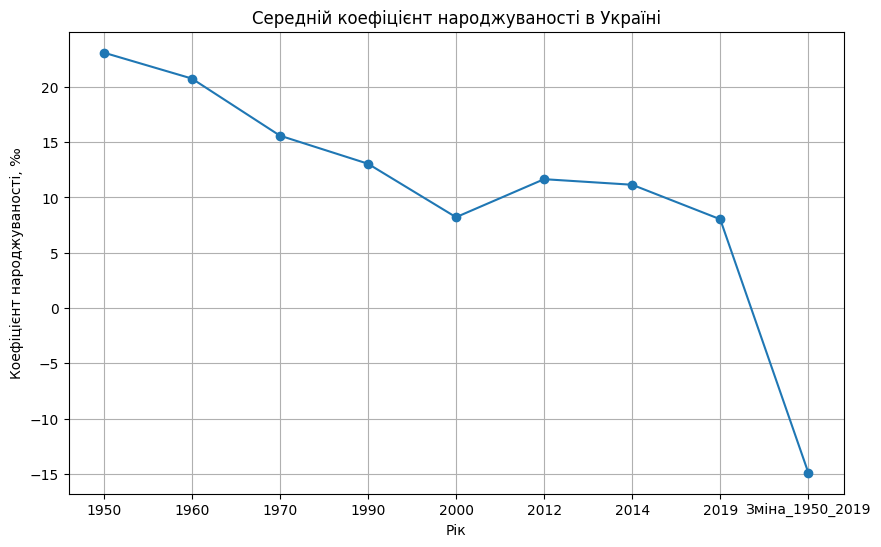

In [82]:
import matplotlib.pyplot as plt

mean_by_year.plot(
    kind="line",
    marker="o",
    figsize=(10, 6)
)

plt.title("Середній коефіцієнт народжуваності в Україні")
plt.xlabel("Рік")
plt.ylabel("Коефіцієнт народжуваності, ‰")
plt.grid(True)

plt.show()

Показує, як у середньому змінювався рівень народжуваності в Україні протягом досліджуваного періоду.

Теплова карта кореляцій

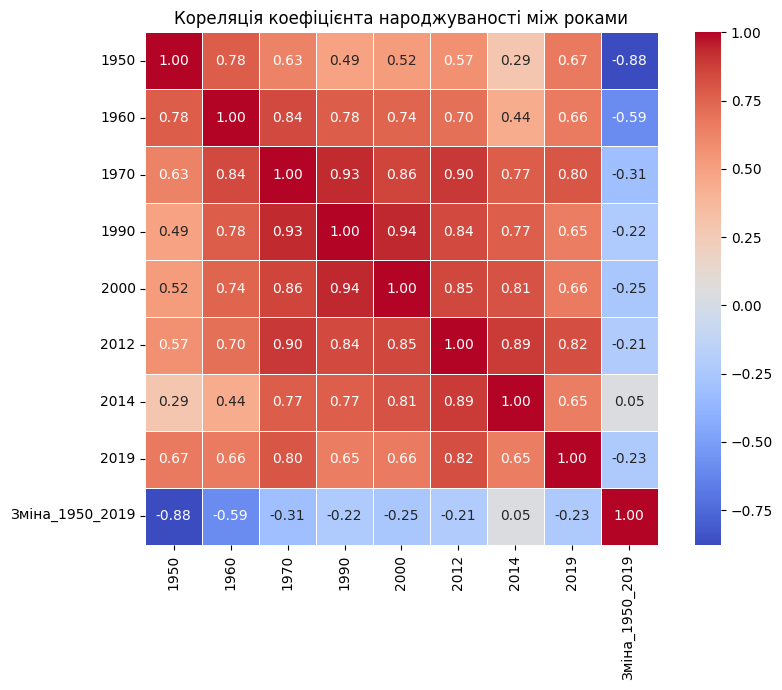

In [83]:
import seaborn as sns

corr = df[year_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Кореляція коефіцієнта народжуваності між роками")
plt.tight_layout()

plt.show()

**Висновок:** У ході роботи було проведено аналіз даних про коефіцієнт народжуваності в регіонах України. Було виконано завантаження таблиці, очищення даних, перевірку пропущених значень та їх заміну середніми значеннями відповідних стовпців. Також було розраховано основні статистичні показники, визначено регіони з найвищими та найнижчими значеннями і досліджено зміни народжуваності за різні роки. За допомогою графіка і теплової карти було наочно показано динаміку та взаємозв'язок показників. У результаті аналізу видно загальну тенденцію до зниження рівня народжуваності в Україні.